In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,roc_auc_score
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('titanic.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.describe(include = 'object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# since cabin has 90% missing data so this columns should be dropped
df.drop(['Cabin'],axis = 1,inplace = True)

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [12]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [14]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [15]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.',expand = False)

In [16]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr


In [17]:
df['Title'].value_counts()

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Title, dtype: int64

In [18]:
df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

In [19]:
df['Title'].value_counts()

Mr          517
Miss        185
Mrs         126
Master       40
Dr            7
Rev           6
Major         2
Col           2
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: Title, dtype: int64

In [20]:
df['Title'] = df['Title'].replace(['Dr','Rev','Major','Col','Don','Lady','Sir','Capt','Countess','Jonkheer'],'Rare')

In [21]:
df['Title'].value_counts()

Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: Title, dtype: int64

In [22]:
df['FamilySize'] = df['SibSp']+df['Parch'] +1 

In [23]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,1


In [24]:
df.drop(columns = ['PassengerId','Name','Ticket'],inplace = True)

In [25]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,Mr,2
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2
2,1,3,female,26.0,0,0,7.9250,S,Miss,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2
4,0,3,male,35.0,0,0,8.0500,S,Mr,1


In [26]:
# Title VS Survived Chi2 Test

In [27]:
# H0:title is important feature for Survived 
# H1:title is not important feature for Survived

In [28]:
title_chi = pd.crosstab(df['Title'],df['Survived'])
chi2,p,dof,eft = stats.chi2_contingency(title_chi)

In [29]:
print(chi2)
print(p)
print(dof)
print(eft)

288.11825659554046
3.957861347159745e-61
4
[[ 24.64646465  15.35353535]
 [113.98989899  71.01010101]
 [318.55555556 198.44444444]
 [ 77.63636364  48.36363636]
 [ 14.17171717   8.82828283]]


In [30]:
title_chi

Survived,0,1
Title,,
Master,17,23
Miss,55,130
Mr,436,81
Mrs,26,100
Rare,15,8


In [31]:
#since P < 0.05 so there is sufficient evidence to conclude that title is significantly important for survival

In [32]:
# ttest Age Vs Survived
sur = df[df['Survived'] == 1]['Age']
notSur = df[df['Survived'] == 0]['Age']

In [33]:
stats.ttest_ind(sur,notSur)

Ttest_indResult(statistic=-1.9394659179476366, pvalue=0.0527606884758555)

In [34]:
#“Age shows a difference between survived and non-survived passengers, but the effect is weak and not statistically strong at the 5% level.”

In [35]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,Mr,2
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2
2,1,3,female,26.0,0,0,7.9250,S,Miss,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2
4,0,3,male,35.0,0,0,8.0500,S,Mr,1


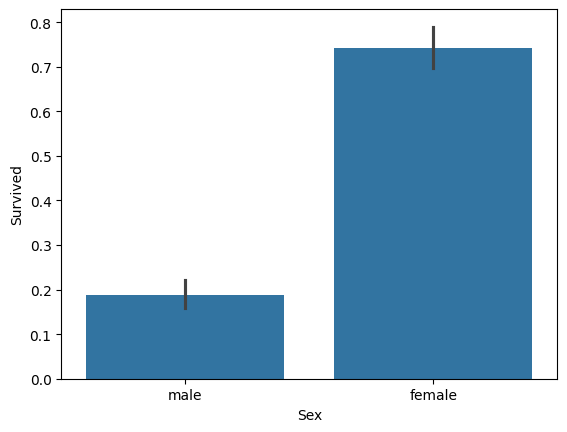

In [36]:
#Survival by sex
sns.barplot(x = 'Sex',y = 'Survived',data = df)
plt.show()

In [37]:
df.groupby('Sex')['Survived'].value_counts(normalize = True)

Sex     Survived
female  1           0.742038
        0           0.257962
male    0           0.811092
        1           0.188908
Name: Survived, dtype: float64

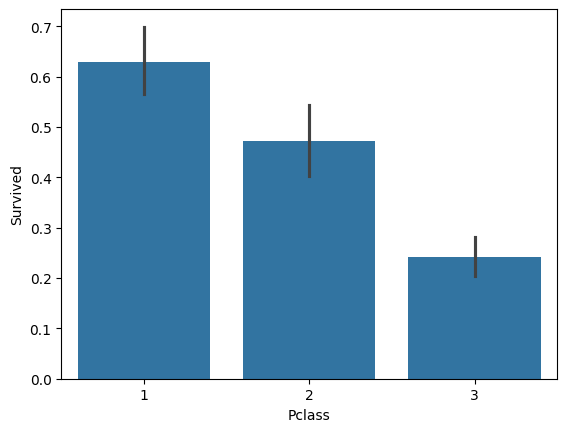

In [38]:
# Survival by Pclass
sns.barplot(x = 'Pclass',y = 'Survived',data = df)
plt.show()

In [39]:
df.groupby('Pclass')['Survived'].value_counts(normalize = True)

Pclass  Survived
1       1           0.629630
        0           0.370370
2       0           0.527174
        1           0.472826
3       0           0.757637
        1           0.242363
Name: Survived, dtype: float64

In [40]:
# from data and visualization we can conclude that the women is survived more and class wise effect is also there.

In [41]:
df.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,Mr,2
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2


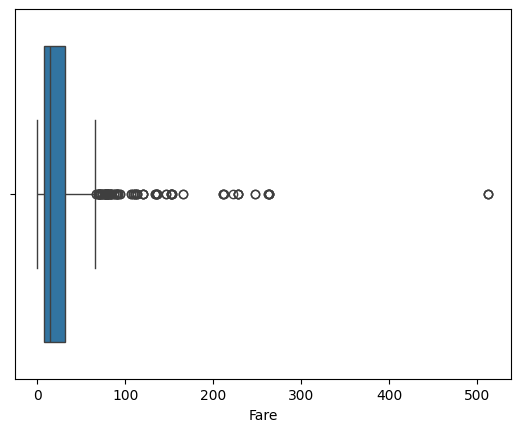

In [42]:
sns.boxplot(x = df['Fare'])
plt.show()

In [43]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
Upper = Q3 + IQR
df['Fare'] = np.where(df['Fare'] > Upper,Upper,df['Fare'])


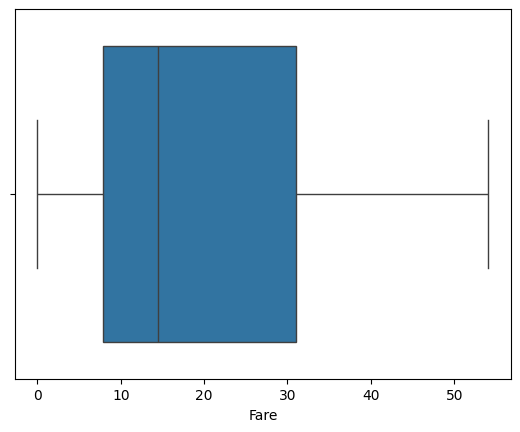

In [44]:
sns.boxplot(x = df['Fare'])
plt.show()

In [45]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,Mr,2
1,1,1,female,38.0,1,0,54.0896,C,Mrs,2
2,1,3,female,26.0,0,0,7.9250,S,Miss,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2
4,0,3,male,35.0,0,0,8.0500,S,Mr,1


In [46]:
le = LabelEncoder()

In [47]:
df['Sex'] = le.fit_transform(df['Sex'])

In [48]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,0,3,1,22.0,1,0,7.2500,S,Mr,2
1,1,1,0,38.0,1,0,54.0896,C,Mrs,2
2,1,3,0,26.0,0,0,7.9250,S,Miss,1
3,1,1,0,35.0,1,0,53.1000,S,Mrs,2
4,0,3,1,35.0,0,0,8.0500,S,Mr,1


In [49]:
df = pd.get_dummies(df,drop_first = True)

In [50]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,1,22.0,1,0,7.2500,2,0,1,0,1,0,0
1,1,1,0,38.0,1,0,54.0896,2,0,0,0,0,1,0
2,1,3,0,26.0,0,0,7.9250,1,0,1,1,0,0,0
3,1,1,0,35.0,1,0,53.1000,2,0,1,0,0,1,0
4,0,3,1,35.0,0,0,8.0500,1,0,1,0,1,0,0


In [51]:
df = df.drop(columns = ['SibSp','Parch'])

In [52]:
X = df.drop(['Survived'],axis = 1)
y = df['Survived']

In [53]:
X.head()

,Pclass,Sex,Age,Fare,FamilySize,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,1,22.0,7.2500,2,0,1,0,1,0,0
1,1,0,38.0,54.0896,2,0,0,0,0,1,0
2,3,0,26.0,7.9250,1,0,1,1,0,0,0
3,1,0,35.0,53.1000,2,0,1,0,0,1,0
4,3,1,35.0,8.0500,1,0,1,0,1,0,0


In [54]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [55]:
X.shape

(891, 11)

In [56]:
y.shape

(891,)

In [57]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 7)

In [58]:
scaler = StandardScaler()

In [59]:
x_train = scaler.fit_transform(x_train)


In [60]:
x_test = scaler.transform(x_test)

In [61]:
lr = LogisticRegression()

In [62]:
lr.fit(x_train,y_train)

LogisticRegression()

In [63]:
y_prob_lr = lr.predict_proba(x_test)[:,1]
roc_auc_score(y_test,y_prob_lr)

0.834848484848485

In [64]:
fpr,tpr,_ = roc_curve(y_test,y_prob_lr)

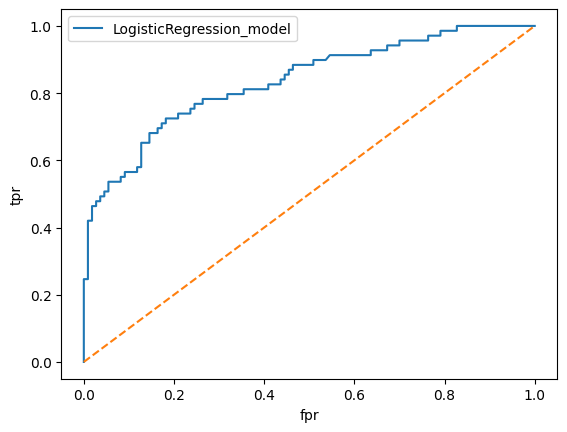

In [65]:
plt.plot(fpr,tpr,label = 'LogisticRegression_model')
plt.plot([0,1],[0,1],'--')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.legend()
plt.show()


In [66]:
rf = RandomForestClassifier(random_state = 7)

In [67]:
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=7)

In [68]:
y_prob_rf = rf.predict_proba(x_test)[:,1]
roc_auc_score(y_test,y_prob_rf)

0.8300395256916996

In [69]:
fpr,tpr,_ = roc_curve(y_test,y_prob_rf)

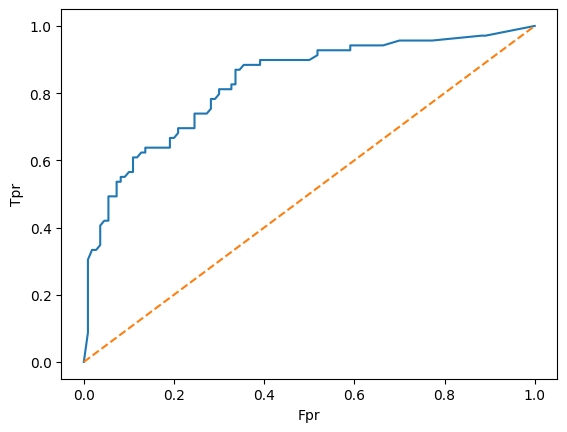

In [70]:
plt.plot(fpr,tpr,label = 'RandomForestClassifier_model')
plt.plot([0,1],[0,1],'--')
plt.xlabel('Fpr')
plt.ylabel('Tpr')
plt.show()

In [71]:
# GridSearchCV
param_grid = { 'n_estimators':[100,200],
              'max_depth':['none',5,10],
               'min_samples_split':[2,5]}

In [72]:
grid = GridSearchCV(RandomForestClassifier(random_state = 7),
                    param_grid,
                    cv = 5,
                    scoring = 'roc_auc',
                    n_jobs = -1)
                    
                    
                    

In [73]:
grid.fit(x_train,y_train)


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py", line 340, in fit
    self._validate_params()
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py", line 600, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Admin\anaconda3\Lib\site-package

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=7), n_jobs=-1,
             param_grid={'max_depth': ['none', 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [74]:
grid.best_params_

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

In [75]:
param_dist = { 'n_estimators':[100,200,300],
               'max_depth':['none',5,10,20],
                'min_samples_split':[2,5,10]}

In [76]:
rand = RandomizedSearchCV(
    RandomForestClassifier(random_state = 7),
    param_dist,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = -1,
    random_state = 7)

In [77]:
rand.fit(x_train,y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py", line 340, in fit
    self._validate_params()
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py", line 600, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Admin\anaconda3\Lib\site-package

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=7),
                   n_jobs=-1,
                   param_distributions={'max_depth': ['none', 5, 10, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=7, scoring='roc_auc')

In [78]:
rand.best_params_

{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 5}

In [79]:
best_rf = rand.best_estimator_

In [80]:
y_prob_best_rf = best_rf.predict_proba(x_test)[:,1]

In [81]:
roc_auc_score(y_test,y_prob_best_rf)

0.8429512516469039

In [82]:
fpr,tpr,_ = roc_curve(y_test,y_prob_best_rf)

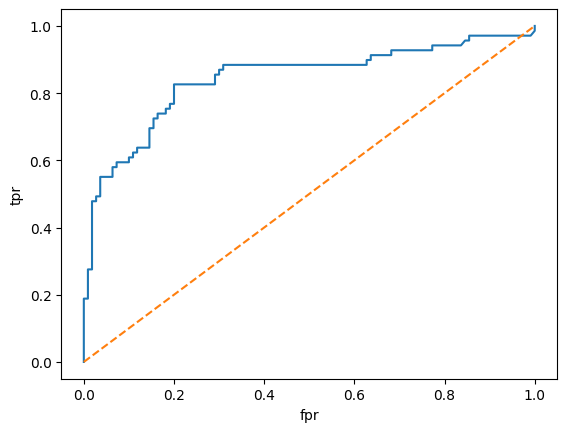

In [83]:
plt.plot(fpr,tpr,label = 'RandomizedSearchCV_model')
plt.plot([0,1],[0,1],'--')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.show()

In [84]:
best_gr = grid.best_estimator_

In [85]:
pred = best_gr.predict_proba(x_test)[:,1]

In [86]:
roc_auc_score(y_test,pred)

0.8429512516469039

In [87]:
import pickle
# Save Trained Model
with open('model.pkl','wb')as f:
    pickle.dump(best_rf,f)
# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully")

Model and scaler saved successfully
